# Características básicas de los establecimientos educacionales

Objetivo:
- Describir las características generales de los establecimientos educacionales que rindieron la prueba SIMCE Matemáticas de segundo medio el 2024

Datos utilizados:
- Puntajes SIMCE Matemáticas 2do medio (2024)

# Cargar librerías y datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
path = '/Users/vcanalesg/Documents/diplomado_dcc/0_taller_proyecto/datos'
simce = pd.read_csv(path + '/simce2m2024_rbd_preliminar.csv', encoding='latin-1', sep=';')
simce.head()

,rbd,dvrbd,nom_rbd,cod_reg_rbd,nom_reg_rbd,cod_pro_rbd,nom_pro_rbd,cod_com_rbd,nom_com_rbd,cod_deprov_rbd,...,palu_eda_ele_lect2m_rbd,palu_eda_ade_lect2m_rbd,palu_eda_ins_mate2m_rbd,palu_eda_ele_mate2m_rbd,palu_eda_ade_mate2m_rbd,noaplica,codigo_bbdd,fecha_bbdd,grado,agno
0,7826,3,COLEGIO SAN MIGUEL,10,DE LOS LAGOS,101,LLANQUIHUE,10102,CALBUCO,101,...,31.0,12.0,62.3,29.2,8.5,0,preliminar20240422v1,20250422,2m,2024
1,6830,6,COLEGIO NUESTRA SENORA DEL CARMEN,14,DE LOS RÍOS,141,VALDIVIA,14101,VALDIVIA,141,...,31.0,23.9,66.7,24.4,9.0,0,preliminar20240422v1,20250422,2m,2024
2,40126,9,COLEGIO RAUL SILVA HENRIQUEZ,4,DE COQUIMBO,43,LIMARÍ,4301,OVALLE,42,...,26.9,9.0,71.6,22.4,6.0,0,preliminar20240422v1,20250422,2m,2024
3,18237,0,COLEGIO AMANECER SAN CARLOS,8,DEL BIOBÍO,81,CONCEPCIÓN,8108,SAN PEDRO DE LA PAZ,83,...,23.8,23.8,46.4,27.4,26.2,0,preliminar20240422v1,20250422,2m,2024
4,14324,3,COLEGIO WILLIAM JAMES,5,DE VALPARAÍSO,51,VALPARAÍSO,5109,VIÑA DEL MAR,53,...,0.0,0.0,45.5,45.5,9.1,0,preliminar20240422v1,20250422,2m,2024


# Preprocesamiento

## Variables categóricas

In [ ]:
# agregar categorías para gráfico
simce['cod_grupo_label'] = simce['cod_grupo'].map({1: 'Bajo', 2: 'Medio-bajo', 3: 'Medio', 4: 'Medio-alto', 5: 'Alto'})
simce['cod_depe2_label'] = simce['cod_depe2'].map({1: 'Municipal', 2: 'Particular Subvencionado', 3: 'Particular Pagado', 4: 'Servicio Local de Educación'})
simce['cod_rural_rbd_label'] = simce['cod_rural_rbd'].map({1: 'Urbano', 2: 'Rural'})

# definir orden categorías
simce['cod_grupo_label'] = pd.Categorical(simce['cod_grupo_label'], categories=['Bajo', 'Medio-bajo', 'Medio', 'Medio-alto', 'Alto'], ordered=True)
simce['cod_depe2_label'] = pd.Categorical(simce['cod_depe2_label'], categories=['Municipal', 'Particular Subvencionado', 'Particular Pagado', 'Servicio Local de Educación'], ordered=True)
simce['cod_rural_rbd_label'] = pd.Categorical(simce['cod_rural_rbd_label'], categories=['Urbano', 'Rural'], ordered=True)

# orden específico para regiones (de norte a sur)
orden_regiones = [15, 1, 2, 3, 4, 5, 13, 6, 7, 8, 16, 9, 14, 10, 11, 12]
simce['cod_reg_rbd'] = pd.Categorical(simce['cod_reg_rbd'], categories=orden_regiones, ordered=True)

# Características generales

El conjunto de datos de la prueba SIMCE 2024 para segundo medio está compuesta por 3.000 establecimientos a nivel nacional.

La mayor parte de los establecimientos educativos se encuentra en las zonas urbanas del país, lo que se condice con cómo se distribuye la población en el territorio nacional. En particular, 2.829 establecimientos se encuentran en la zona urbana.

De la misma manera, la Región Metropolitana concentra la mayor parte de los establecimientos (1.061), seguidos por la región de Valparaíso (388) y la del Bíobio (251).

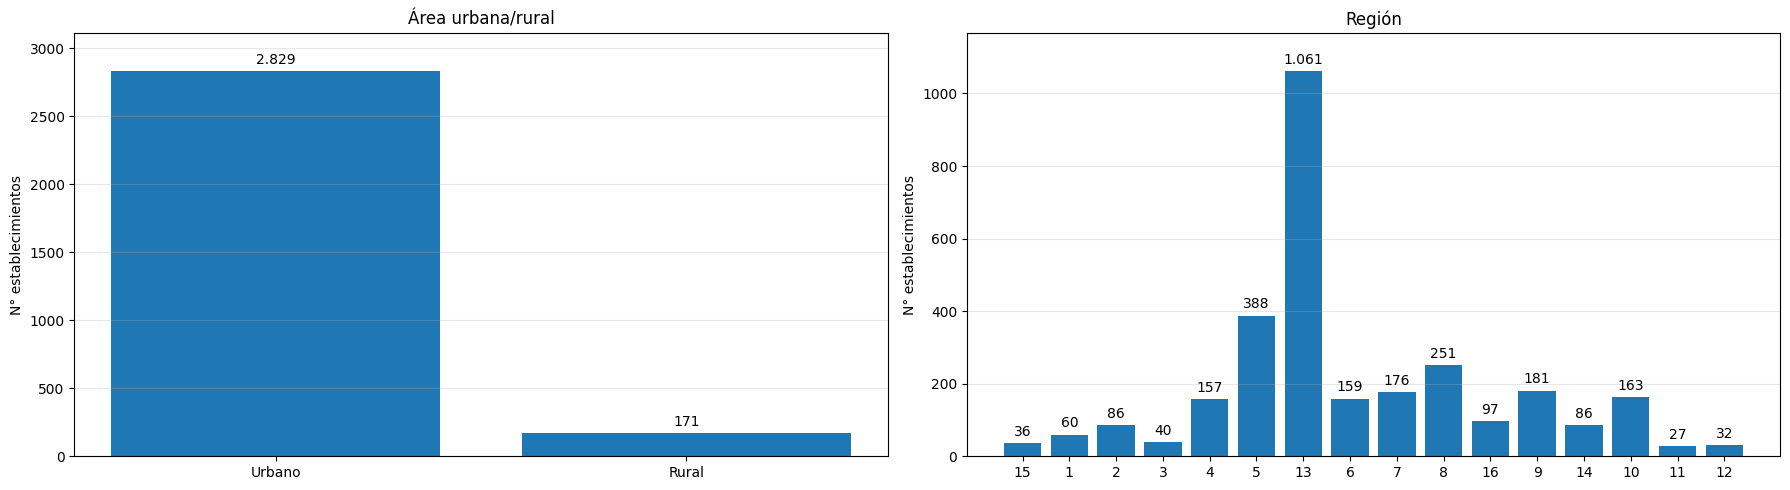

In [28]:
cat_vars = ['cod_rural_rbd_label', 'cod_reg_rbd']

# títulos para cada gráfico
titulos = {
    'cod_rural_rbd_label': 'Área urbana/rural',
    'cod_reg_rbd': 'Región'
}

fig, axes = plt.subplots(1, len(cat_vars), figsize=(18, 5))

for ax, var in zip(axes, cat_vars):
    counts = simce[var].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values)
    ax.bar_label(bars, padding=3, fmt=lambda x: f'{int(x):,}'.replace(',', '.'))
    ax.margins(y=0.1)
    ax.set_title(titulos.get(var, var))
    ax.set_ylabel('N° establecimientos')
    ax.tick_params(axis='x')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

En términos de dependencia administrativa, los establecimientos particulares subvencionados encabezan el número de establecimientos que rindieron el SIMCE (1.682 establecimientos), seguidos por los establecimientos de caracter municipal. Los establecimientos dependientes de los Servicios Locales de Educación siguen siendo minoritarios (163 de 3.000 establecimientos) para el año 2024. Esto está en línea con la implementación gradual de la nueva ley que crea el Sistema de Educación Pública el 2017 y que establece la creación de estos servicios.

La mayor parte de los establecimientos atiende a estudiantes de grupo socioeconómico (GSE) medio o bajo. Así, 867 de los 3.000 establecimientos son clasificados en el GSE medio-bajo y 693 en el GSE bajo. 433 establecimientos atienden estudiantes de nivel socioeconómico alto.

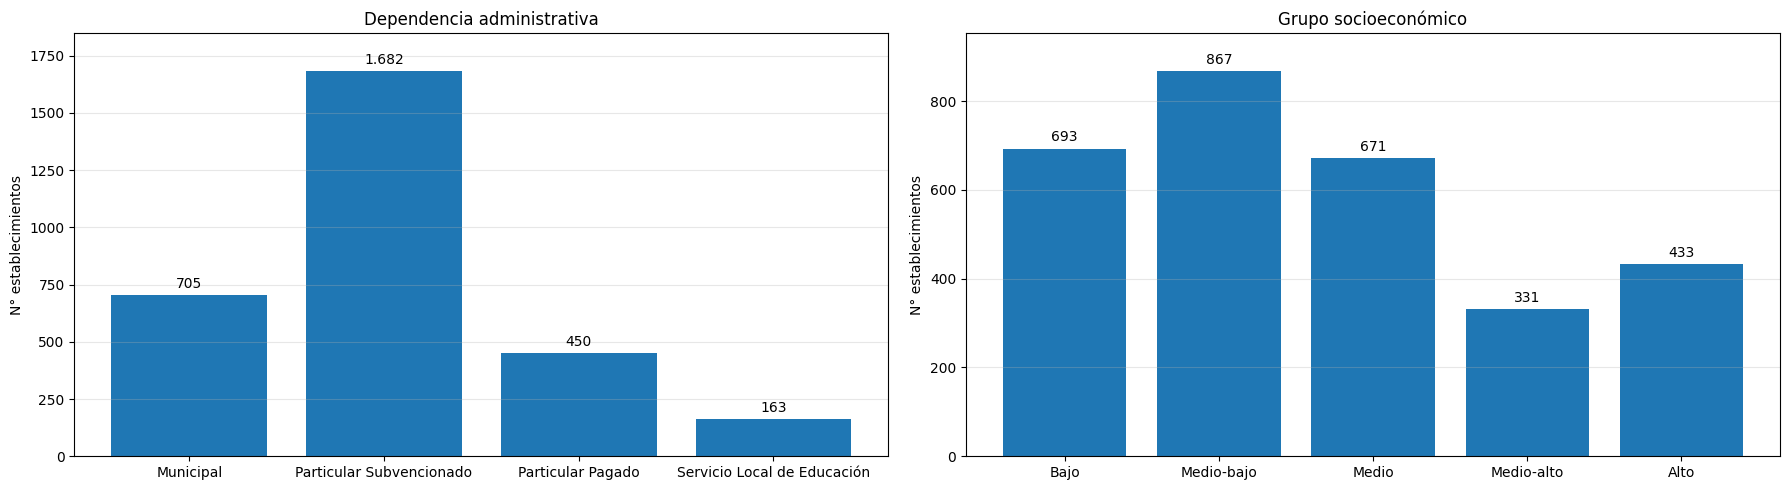

In [ ]:
cat_vars = ['cod_depe2_label', 'cod_grupo_label']

# títulos para cada gráfico
titulos = {
    'cod_depe2_label': 'Dependencia administrativa',
    'cod_grupo_label': 'Grupo socioeconómico',
}

fig, axes = plt.subplots(1, len(cat_vars), figsize=(18, 5))

for ax, var in zip(axes, cat_vars):
    counts = simce[var].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values)
    ax.bar_label(bars, padding=3, fmt=lambda x: f'{int(x):,}'.replace(',', '.'))
    ax.margins(y=0.1)
    ax.set_title(titulos.get(var, var))
    ax.set_ylabel('N° establecimientos')
    ax.tick_params(axis='x')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()